# WAC Price Change — Clustering Modeling
**Approach**: Aggregate per-material behavioral features → K-Means + GMM clustering → export cluster labels for downstream Random Forest models.

> Note: *K-Nearest Neighbors (KNN)* is a supervised classifier. The unsupervised K-based clustering algorithm is **K-Means**, used here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA


### Step 1 — Load Data, Derive Price-Change Flag & Split Train/Validation
> **Leakage fix**: clusters are fitted on **training data only** (pre-2024).  
> Validation-period rows are assigned to clusters via `predict()` — no future information leaks into the cluster model.

In [2]:
df = pd.read_csv('../data/real_data/No_leakage_Active_COPA_data.csv',
                 dtype={'COPA_NDC_NUM': str, 'COPA_MTRL_NUM': str})
df['WAC_PRICE_COPA_DATE'] = pd.to_datetime(df['WAC_PRICE_COPA_DATE'])
df = df[df['IS_FUTURE_PERIOD_FLAG'] == 0].copy()

# Price-change flag
df['PRICE_CHANGED'] = (df['BASELINE_MOM_VAR_PCT'].fillna(0) > 0).astype(int)

# ── Train/validation split — mirrors tree modeling notebook ──
TRAIN_CUTOFF = '2024-01-01'
VAL_END      = '2025-01-01'

train_df = df[df['WAC_PRICE_COPA_DATE'] <  TRAIN_CUTOFF].copy()
val_df   = df[(df['WAC_PRICE_COPA_DATE'] >= TRAIN_CUTOFF) &
              (df['WAC_PRICE_COPA_DATE'] <  VAL_END)].copy()

print(f'Total rows      : {len(df):,}')
print(f'Training rows   : {len(train_df):,}  (< {TRAIN_CUTOFF})')
print(f'Validation rows : {len(val_df):,}  ({TRAIN_CUTOFF} – {VAL_END})')
print(f'Unique materials in train : {train_df["COPA_MTRL_NUM"].nunique():,}')
print(f'Unique materials in val   : {val_df["COPA_MTRL_NUM"].nunique():,}')

# ── Join therapeutic class + manufacturer from Baseline_model_input ──
baseline = pd.read_csv('../data/real_data/Baseline_model_input.csv',
                        dtype={'MTRL_NUM': str})
baseline['COPA_MTRL_NUM'] = baseline['MTRL_NUM'].str.zfill(18)
baseline_dedup = (baseline.drop_duplicates('COPA_MTRL_NUM')
                          [['COPA_MTRL_NUM','THERAPEUTIC_CLASS','MANUFACTURER_NAME']])

df = df.merge(baseline_dedup, on='COPA_MTRL_NUM', how='left')

# ── LOE year via SELL_DSCR substring match ──
import openpyxl
loe_wb  = openpyxl.load_workbook(
    '../data/real_data/Top_500_Revenue_Materials_BT_05292026_v1.xlsx',
    read_only=True, data_only=True)
loe_ws  = loe_wb['LOE_Data']
loe_rows = list(loe_ws.values)
loe_df  = pd.DataFrame(loe_rows[1:], columns=loe_rows[0])
loe_df.columns = loe_df.columns.str.strip()
loe_df  = loe_df.dropna(subset=[loe_df.columns[0], loe_df.columns[1]])
loe_df.columns = ['PRODUCT_FAMILY', 'LOE_YEAR']
loe_df['LOE_YEAR'] = pd.to_numeric(loe_df['LOE_YEAR'], errors='coerce')
loe_map = dict(zip(loe_df['PRODUCT_FAMILY'].str.upper(), loe_df['LOE_YEAR']))
families_sorted = sorted(loe_map.keys(), key=len, reverse=True)

def match_loe(dscr):
    d = str(dscr).upper()
    for fam in families_sorted:
        if fam in d:
            return loe_map[fam]
    return np.nan

df['LOE_YEAR'] = df['SELL_DSCR'].apply(match_loe)
# Fill unmatched with -1 (unknown / not in top-500 LOE list)
df['LOE_YEAR'] = df['LOE_YEAR'].fillna(-1)

# Rebuild train/val with the enriched df
train_df = df[df['WAC_PRICE_COPA_DATE'] <  TRAIN_CUTOFF].copy()
val_df   = df[(df['WAC_PRICE_COPA_DATE'] >= TRAIN_CUTOFF) &
              (df['WAC_PRICE_COPA_DATE'] <  VAL_END)].copy()

print(f'TC coverage   : {df["THERAPEUTIC_CLASS"].notna().mean():.1%}')
print(f'Mfr coverage  : {df["MANUFACTURER_NAME"].notna().mean():.1%}')
print(f'LOE coverage  : {(df["LOE_YEAR"] > 0).mean():.1%}  (>0 = matched to LOE list)')


Total rows      : 267,484
Training rows   : 109,530  (< 2024-01-01)
Validation rows : 61,232  (2024-01-01 – 2025-01-01)
Unique materials in train : 5,288
Unique materials in val   : 5,715
TC coverage   : 96.1%
Mfr coverage  : 98.5%
LOE coverage  : 5.1%  (>0 = matched to LOE list)


### Step 2 — Aggregate to One Row per Material
*(training data only — avoids future leakage into cluster assignments)*

> **Leakage rules for downstream tasks:**
> - **Task 1 (classifier — will price change?)**: cluster must NOT use `CHANGE_FREQ` or change-count features — these are proxies for the classification target.
> - **Task 2 (regressor — how much will WAC change?)**: cluster must NOT use `AVG_CHANGE_PCT` or `MAX_CHANGE_PCT` — these are proxies for the regression target.
> - **Safe features**: structural/exogenous only — product category, tenure, source preference, supply variance metrics.
> - Change-behavior features (`CHANGE_FREQ`, `AVG_CHANGE_PCT` etc.) are computed for **profiling/interpretation only**, not fed into the cluster model.


In [3]:
# Encode product category + manufacturer — fit on training data only
le_cat = LabelEncoder()
train_df['PROD_CAT_ENC'] = le_cat.fit_transform(train_df['CUST_PROD_CATEGORY'].fillna('UNKNOWN'))
val_df['PROD_CAT_ENC'] = val_df['CUST_PROD_CATEGORY'].fillna('UNKNOWN').apply(
    lambda x: le_cat.transform([x])[0] if x in le_cat.classes_ else le_cat.transform(['UNKNOWN'])[0]
)

le_mfr = LabelEncoder()
train_df['MANUFACTURER_ENC'] = le_mfr.fit_transform(train_df['MANUFACTURER_NAME'].fillna('UNKNOWN'))
val_df['MANUFACTURER_ENC'] = val_df['MANUFACTURER_NAME'].fillna('UNKNOWN').apply(
    lambda x: le_mfr.transform([x])[0] if x in le_mfr.classes_ else le_mfr.transform(['UNKNOWN'])[0]
)

def safe_nonzero_mean(s):
    nz = s[s > 0]
    return nz.mean() if len(nz) > 0 else 0.0

def agg_features(data):
    """Aggregate per-material behavioral features.
    NOTE: AVG_WAC / STD_WAC / CV_WAC are kept for profiling only —
    NOT included in clustering features to avoid encoding the WAC price target.
    """
    return data.groupby('COPA_MTRL_NUM').agg(
        TENURE_MONTHS      = ('WAC_PRICE_COPA_DATE', 'count'),
        AVG_WAC            = ('BASELINE_WAC_PRICE', 'mean'),   # profile only
        STD_WAC            = ('BASELINE_WAC_PRICE', 'std'),    # profile only
        N_PRICE_CHANGES    = ('PRICE_CHANGED', 'sum'),
        CHANGE_FREQ        = ('PRICE_CHANGED', 'mean'),
        AVG_CHANGE_PCT     = ('BASELINE_MOM_VAR_PCT', safe_nonzero_mean),
        MAX_CHANGE_PCT     = ('BASELINE_MOM_VAR_PCT', 'max'),
        AVG_COPA_VARIANCE  = ('AVG_COPA_VARIANCE', 'mean'),
        AVG_SNW_VARIANCE   = ('AVG_SNW_VARIANCE', 'mean'),
        PREF_SNW_RATE      = ('PREFERRED_SOURCE', lambda x: (x == 'SNW').mean()),
        PROD_CAT_ENC       = ('PROD_CAT_ENC', 'first'),
        CUST_PROD_CATEGORY = ('CUST_PROD_CATEGORY', 'first'),
        MANUFACTURER_ENC   = ('MANUFACTURER_ENC', 'first'),    # manufacturer identity
        MANUFACTURER_NAME  = ('MANUFACTURER_NAME', 'first'),   # profile only
        THERAPEUTIC_CLASS  = ('THERAPEUTIC_CLASS', 'first'),   # numeric TC code
        LOE_YEAR           = ('LOE_YEAR', 'first'),            # loss-of-exclusivity year (-1 = unknown)
    ).reset_index()

# ── Training aggregates: fit cluster model on this ──
mat_train = agg_features(train_df)
mat_train['CV_WAC'] = (mat_train['STD_WAC'] / mat_train['AVG_WAC'].replace(0, np.nan)).fillna(0)
mat_train = mat_train[mat_train['TENURE_MONTHS'] >= 6].copy()

# ── Validation aggregates: MUST use training-period history only ──
# Leakage fix: do NOT aggregate val_df to get val features.
# Instead, take each validation material's pre-2024 history from train_df.
# This means cluster features for validation reflect only what we knew BEFORE
# the validation period started — no future WAC values, no future price changes.
val_mtrls = val_df['COPA_MTRL_NUM'].unique()
train_hist_for_val = train_df[train_df['COPA_MTRL_NUM'].isin(val_mtrls)].copy()

mat_val = agg_features(train_hist_for_val)
mat_val['CV_WAC'] = (mat_val['STD_WAC'] / mat_val['AVG_WAC'].replace(0, np.nan)).fillna(0)

# Materials in validation with no training history (brand-new in 2024)
new_in_val = set(val_mtrls) - set(mat_val['COPA_MTRL_NUM'])
print(f'Training materials (>=6m)                     : {len(mat_train):,}')
print(f'Validation materials with training history    : {len(mat_val):,}')
print(f'Validation materials with NO training history : {len(new_in_val):,}  (will get NaN cluster)')


Training materials (>=6m)                     : 4,896
Validation materials with training history    : 5,048
Validation materials with NO training history : 667  (will get NaN cluster)


### Step 3 — Feature Matrix & Scaling
*(scaler fitted on training aggregates only, applied to both train and val)*

In [4]:
# Safe clustering features — structural/exogenous only.
# Excluded to prevent target leakage:
#   CHANGE_FREQ / N_PRICE_CHANGES  → proxy for classifier target (did price change?)
#   AVG_CHANGE_PCT / MAX_CHANGE_PCT → proxy for regressor target (how much did WAC change?)
#   CV_WAC / AVG_WAC / STD_WAC      → proxy for regressor target (price level)
CLUSTER_FEATURES = [
    'TENURE_MONTHS',       # how long material has been active
    'PREF_SNW_RATE',       # structural: preferred price source
    'AVG_COPA_VARIANCE',   # structural: supply-side variance
    'AVG_SNW_VARIANCE',    # structural: supply-side variance
    'PROD_CAT_ENC',        # product category (exogenous)
    'THERAPEUTIC_CLASS',   # numeric therapeutic class code
    'MANUFACTURER_ENC',    # manufacturer identity (label-encoded)
    'LOE_YEAR',            # loss-of-exclusivity year (-1 = unknown/not top-500)
]

X_train_raw = mat_train[CLUSTER_FEATURES].fillna(0).values
X_val_raw   = mat_val[CLUSTER_FEATURES].fillna(0).values

# Fit scaler on training only
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape  : {X_val.shape}')
print(f'Cluster features (leakage-safe): {CLUSTER_FEATURES}')
print()
print('Held out for profiling only (NOT used in clustering):')
print('  CHANGE_FREQ, N_PRICE_CHANGES  — would leak classifier target')
print('  AVG_CHANGE_PCT, MAX_CHANGE_PCT — would leak regressor target')
print('  CV_WAC, AVG_WAC, STD_WAC       — would leak WAC price level (regressor target)')


X_train shape: (4896, 8)
X_val shape  : (5048, 8)
Cluster features (leakage-safe): ['TENURE_MONTHS', 'PREF_SNW_RATE', 'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'PROD_CAT_ENC', 'THERAPEUTIC_CLASS', 'MANUFACTURER_ENC', 'LOE_YEAR']

Held out for profiling only (NOT used in clustering):
  CHANGE_FREQ, N_PRICE_CHANGES  — would leak classifier target
  AVG_CHANGE_PCT, MAX_CHANGE_PCT — would leak regressor target
  CV_WAC, AVG_WAC, STD_WAC       — would leak WAC price level (regressor target)


### Step 4 — K-Means: Elbow & Silhouette to Choose K

  k= 2  inertia=34,383  silhouette=0.2277
  k= 3  inertia=29,619  silhouette=0.2533
  k= 4  inertia=25,274  silhouette=0.2479
  k= 5  inertia=23,289  silhouette=0.2808
  k= 6  inertia=19,038  silhouette=0.3058
  k= 7  inertia=15,628  silhouette=0.3080
  k= 8  inertia=13,639  silhouette=0.2827
  k= 9  inertia=12,377  silhouette=0.2827
  k=10  inertia=11,551  silhouette=0.2840
  k=11  inertia=10,305  silhouette=0.2930


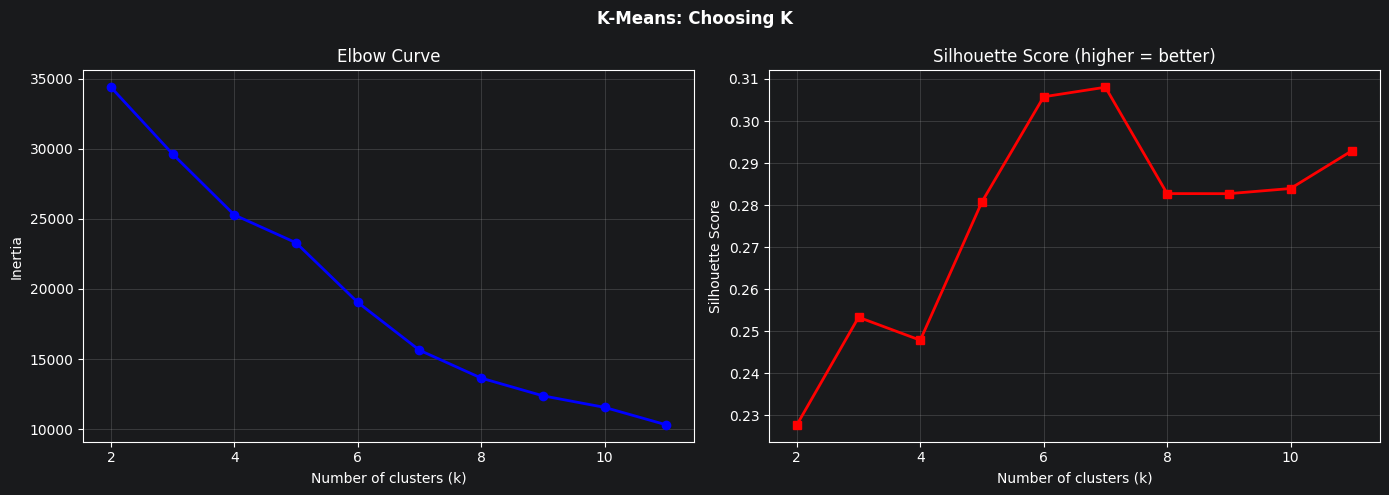


Best k by silhouette: 7  (score=0.3080)


In [5]:
K_RANGE = range(2, 12)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train, labels))
    print(f'  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means: Choosing K', fontweight='bold')
axes[0].plot(list(K_RANGE), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve'); axes[0].grid(alpha=0.3)
axes[1].plot(list(K_RANGE), sil_scores, 'rs-', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_k_sil = list(K_RANGE)[sil_scores.index(max(sil_scores))]
print(f'\nBest k by silhouette: {best_k_sil}  (score={max(sil_scores):.4f})')


### Step 5 — Fit Final K-Means Model

In [6]:
K_FINAL = best_k_sil

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
km_final.fit(X_train)

mat_train['KMEANS_CLUSTER'] = km_final.predict(X_train)
mat_val['KMEANS_CLUSTER']   = km_final.predict(X_val)

print(f'K-Means k={K_FINAL}  |  train silhouette={silhouette_score(X_train, mat_train["KMEANS_CLUSTER"]):.4f}')
print()
print('Train cluster sizes:')
print(mat_train['KMEANS_CLUSTER'].value_counts().sort_index())
print()
print('Val cluster sizes (assigned via predict):')
print(mat_val['KMEANS_CLUSTER'].value_counts().sort_index())


K-Means k=7  |  train silhouette=0.3080

Train cluster sizes:
KMEANS_CLUSTER
0     971
1     680
2    2407
3       2
4     235
5       1
6     600
Name: count, dtype: int64

Val cluster sizes (assigned via predict):
KMEANS_CLUSTER
0     966
1     677
2    2390
3       2
4     247
5       1
6     765
Name: count, dtype: int64


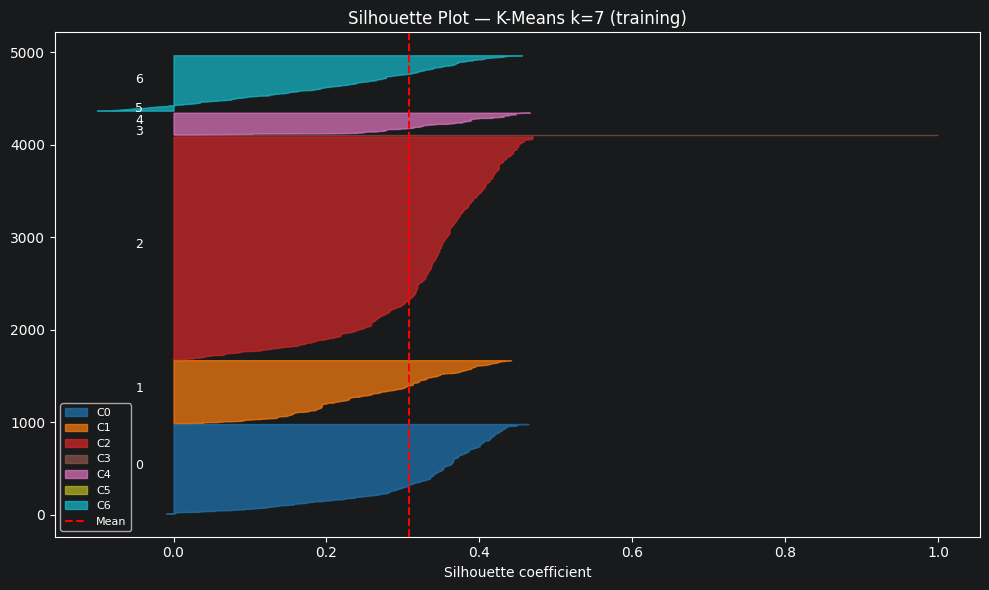

In [7]:
sil_vals = silhouette_samples(X_train, mat_train['KMEANS_CLUSTER'])
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, K_FINAL))
for i in range(K_FINAL):
    ith_vals = np.sort(sil_vals[mat_train['KMEANS_CLUSTER'] == i])
    size_i = len(ith_vals)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, alpha=0.7, color=colors[i], label=f'C{i}')
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=9)
    y_lower = y_upper + 10
ax.axvline(x=silhouette_score(X_train, mat_train['KMEANS_CLUSTER']), color='red', linestyle='--', label='Mean')
ax.set_xlabel('Silhouette coefficient'); ax.set_title(f'Silhouette Plot — K-Means k={K_FINAL} (training)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### Step 6 — K-Means Cluster Profiles

K-Means Cluster Profiles (training materials):


,CHANGE_FREQ,AVG_CHANGE_PCT,MAX_CHANGE_PCT,CV_WAC,TENURE_MONTHS,PREF_SNW_RATE,AVG_WAC,CUST_PROD_CATEGORY,N_MATERIALS
KMEANS_CLUSTER,,,,,,,,,
0,0.0526,0.0743,0.0827,0.0472,24.1359,0.8694,1184.6910,BX,971
1,0.1003,0.0241,0.0357,0.0261,23.2412,0.2473,6605.6465,MPB Specialty,680
2,0.0942,0.0220,0.0364,0.0238,23.6797,0.0364,1351.9846,BX,2407
3,0.6250,0.2381,2.5832,0.4311,24.0000,0.0833,84.0685,BX,2
4,0.2329,0.0187,0.0328,0.0440,23.1574,0.2558,5499.9614,APOLLO,235
5,0.0000,0.0000,0.0000,0.0000,24.0000,0.5000,0.0100,APOLLO,1
6,0.0494,0.0207,0.0261,0.0146,11.1683,0.0400,2491.8632,BX,600


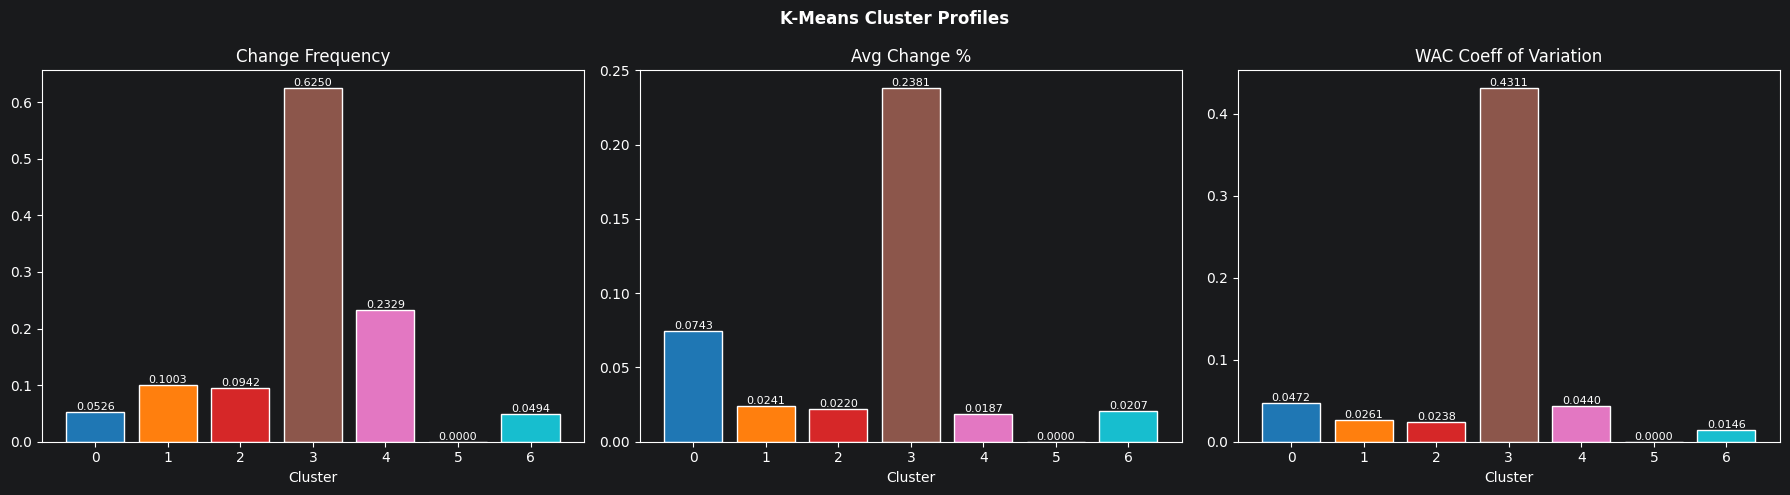

In [8]:
profile_cols = ['CHANGE_FREQ','AVG_CHANGE_PCT','MAX_CHANGE_PCT','CV_WAC',
                'TENURE_MONTHS','PREF_SNW_RATE','AVG_WAC']

km_profile = mat_train.groupby('KMEANS_CLUSTER')[profile_cols + ['CUST_PROD_CATEGORY']].agg(
    {**{c: 'mean' for c in profile_cols},
     'CUST_PROD_CATEGORY': lambda x: x.value_counts().index[0]}
).round(4)
km_profile['N_MATERIALS'] = mat_train.groupby('KMEANS_CLUSTER').size()
print('K-Means Cluster Profiles (training materials):')
display(km_profile)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Means Cluster Profiles', fontweight='bold')
for ax, col, title in zip(axes,
    ['CHANGE_FREQ','AVG_CHANGE_PCT','CV_WAC'],
    ['Change Frequency','Avg Change %','WAC Coeff of Variation']):
    vals = km_profile[col]
    bars = ax.bar(vals.index.astype(str), vals.values,
                  color=cm.tab10(np.linspace(0,1,K_FINAL)), edgecolor='white')
    ax.set_title(title); ax.set_xlabel('Cluster')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()


### Step 7 — GMM: BIC & AIC to Choose Number of Components

  n= 2  BIC=-40,024.4  AIC=-40,602.5
  n= 3  BIC=-51,241.8  AIC=-52,112.3
  n= 4  BIC=-91,529.9  AIC=-92,692.7
  n= 5  BIC=-94,285.5  AIC=-95,740.6
  n= 6  BIC=-115,581.0  AIC=-117,328.5
  n= 7  BIC=-126,788.2  AIC=-128,828.0
  n= 8  BIC=-129,361.4  AIC=-131,693.5
  n= 9  BIC=-129,403.1  AIC=-132,027.6
  n=10  BIC=-137,951.8  AIC=-140,868.5
  n=11  BIC=-131,098.8  AIC=-134,307.9


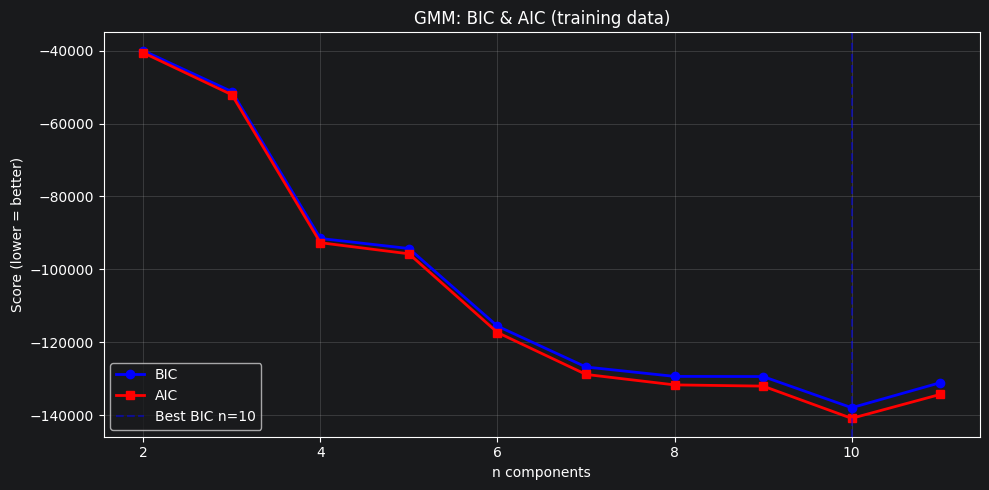


Best n by BIC: 10


In [9]:
N_RANGE = range(2, 12)
bic_scores, aic_scores = [], []
for n in N_RANGE:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5, covariance_type='full')
    gmm.fit(X_train)
    bic_scores.append(gmm.bic(X_train))
    aic_scores.append(gmm.aic(X_train))
    print(f'  n={n:2d}  BIC={bic_scores[-1]:,.1f}  AIC={aic_scores[-1]:,.1f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(N_RANGE), bic_scores, 'bo-', linewidth=2, label='BIC')
ax.plot(list(N_RANGE), aic_scores, 'rs-', linewidth=2, label='AIC')
ax.axvline(x=list(N_RANGE)[np.argmin(bic_scores)], color='blue', linestyle='--', alpha=0.5,
           label=f'Best BIC n={list(N_RANGE)[np.argmin(bic_scores)]}')
ax.set_xlabel('n components'); ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM: BIC & AIC (training data)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_n_bic = list(N_RANGE)[np.argmin(bic_scores)]
print(f'\nBest n by BIC: {best_n_bic}')


### Step 8 — Fit Final GMM

In [10]:
N_FINAL = best_n_bic

gmm_final = GaussianMixture(n_components=N_FINAL, random_state=42, n_init=10, covariance_type='full')
gmm_final.fit(X_train)

mat_train['GMM_CLUSTER']  = gmm_final.predict(X_train)
mat_val['GMM_CLUSTER']    = gmm_final.predict(X_val)

train_proba = gmm_final.predict_proba(X_train)
val_proba   = gmm_final.predict_proba(X_val)
mat_train['GMM_MAX_PROB'] = train_proba.max(axis=1)
mat_val['GMM_MAX_PROB']   = val_proba.max(axis=1)

print(f'GMM n={N_FINAL}  |  train silhouette={silhouette_score(X_train, mat_train["GMM_CLUSTER"]):.4f}')
print(f'Mean train assignment probability: {mat_train["GMM_MAX_PROB"].mean():.3f}')
print()
print('Train cluster sizes:')
print(mat_train['GMM_CLUSTER'].value_counts().sort_index())
print()
print('Val cluster sizes (assigned via predict):')
print(mat_val['GMM_CLUSTER'].value_counts().sort_index())


GMM n=10  |  train silhouette=0.0458
Mean train assignment probability: 0.962

Train cluster sizes:
GMM_CLUSTER
0     346
1    1378
2     538
3       2
4     569
5     229
6       7
7      94
8     215
9    1518
Name: count, dtype: int64

Val cluster sizes (assigned via predict):
GMM_CLUSTER
0     453
1    1431
2     516
3       2
4     569
5     241
6       7
7      96
8     215
9    1518
Name: count, dtype: int64


### Step 9 — GMM Cluster Profiles

GMM Cluster Profiles (training materials):


,CHANGE_FREQ,AVG_CHANGE_PCT,MAX_CHANGE_PCT,CV_WAC,TENURE_MONTHS,PREF_SNW_RATE,AVG_WAC,CUST_PROD_CATEGORY,N_MATERIALS,MEAN_PROB
GMM_CLUSTER,,,,,,,,,,
0,0.0310,0.0123,0.0138,0.0076,16.4393,0.0000,5692.2943,MPB Plasma,346,0.996
1,0.0310,0.0135,0.0198,0.0086,20.6255,0.0000,688.6722,BX,1378,0.901
2,0.0855,0.0364,0.0497,0.0351,22.0056,0.4878,3236.4161,BX,538,0.970
3,0.6250,0.2381,2.5832,0.4311,24.0000,0.0833,84.0685,BX,2,1.000
4,0.0986,0.0121,0.0206,0.0184,24.0000,0.0138,5380.8523,APOLLO,569,0.983
5,0.2390,0.0192,0.0336,0.0452,23.1354,0.2494,5644.0649,APOLLO,229,1.000
6,0.0000,0.0000,0.0000,0.0000,24.0000,0.5000,0.0100,APOLLO,7,1.000
7,0.1001,0.1972,0.2482,0.1657,18.5213,0.2430,1059.6914,BX,94,0.951
8,0.1076,0.0366,0.0508,0.0325,24.0000,0.6957,7331.6056,MPB Specialty,215,0.972


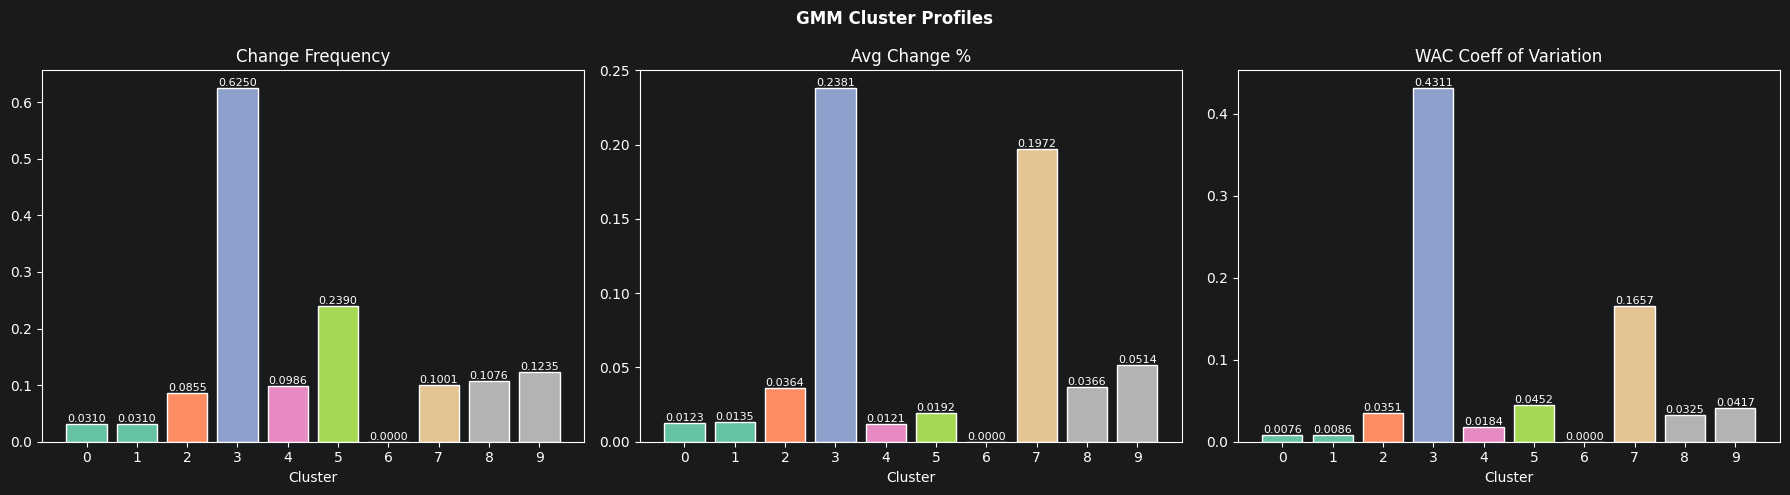

In [11]:
gmm_profile = mat_train.groupby('GMM_CLUSTER')[profile_cols + ['CUST_PROD_CATEGORY']].agg(
    {**{c: 'mean' for c in profile_cols},
     'CUST_PROD_CATEGORY': lambda x: x.value_counts().index[0]}
).round(4)
gmm_profile['N_MATERIALS'] = mat_train.groupby('GMM_CLUSTER').size()
gmm_profile['MEAN_PROB']   = mat_train.groupby('GMM_CLUSTER')['GMM_MAX_PROB'].mean().round(3)
print('GMM Cluster Profiles (training materials):')
display(gmm_profile)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GMM Cluster Profiles', fontweight='bold')
for ax, col, title in zip(axes,
    ['CHANGE_FREQ','AVG_CHANGE_PCT','CV_WAC'],
    ['Change Frequency','Avg Change %','WAC Coeff of Variation']):
    vals = gmm_profile[col]
    bars = ax.bar(vals.index.astype(str), vals.values,
                  color=cm.Set2(np.linspace(0,1,N_FINAL)), edgecolor='white')
    ax.set_title(title); ax.set_xlabel('Cluster')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()


### Step 10 — PCA 2D Visualisation (K-Means vs GMM)

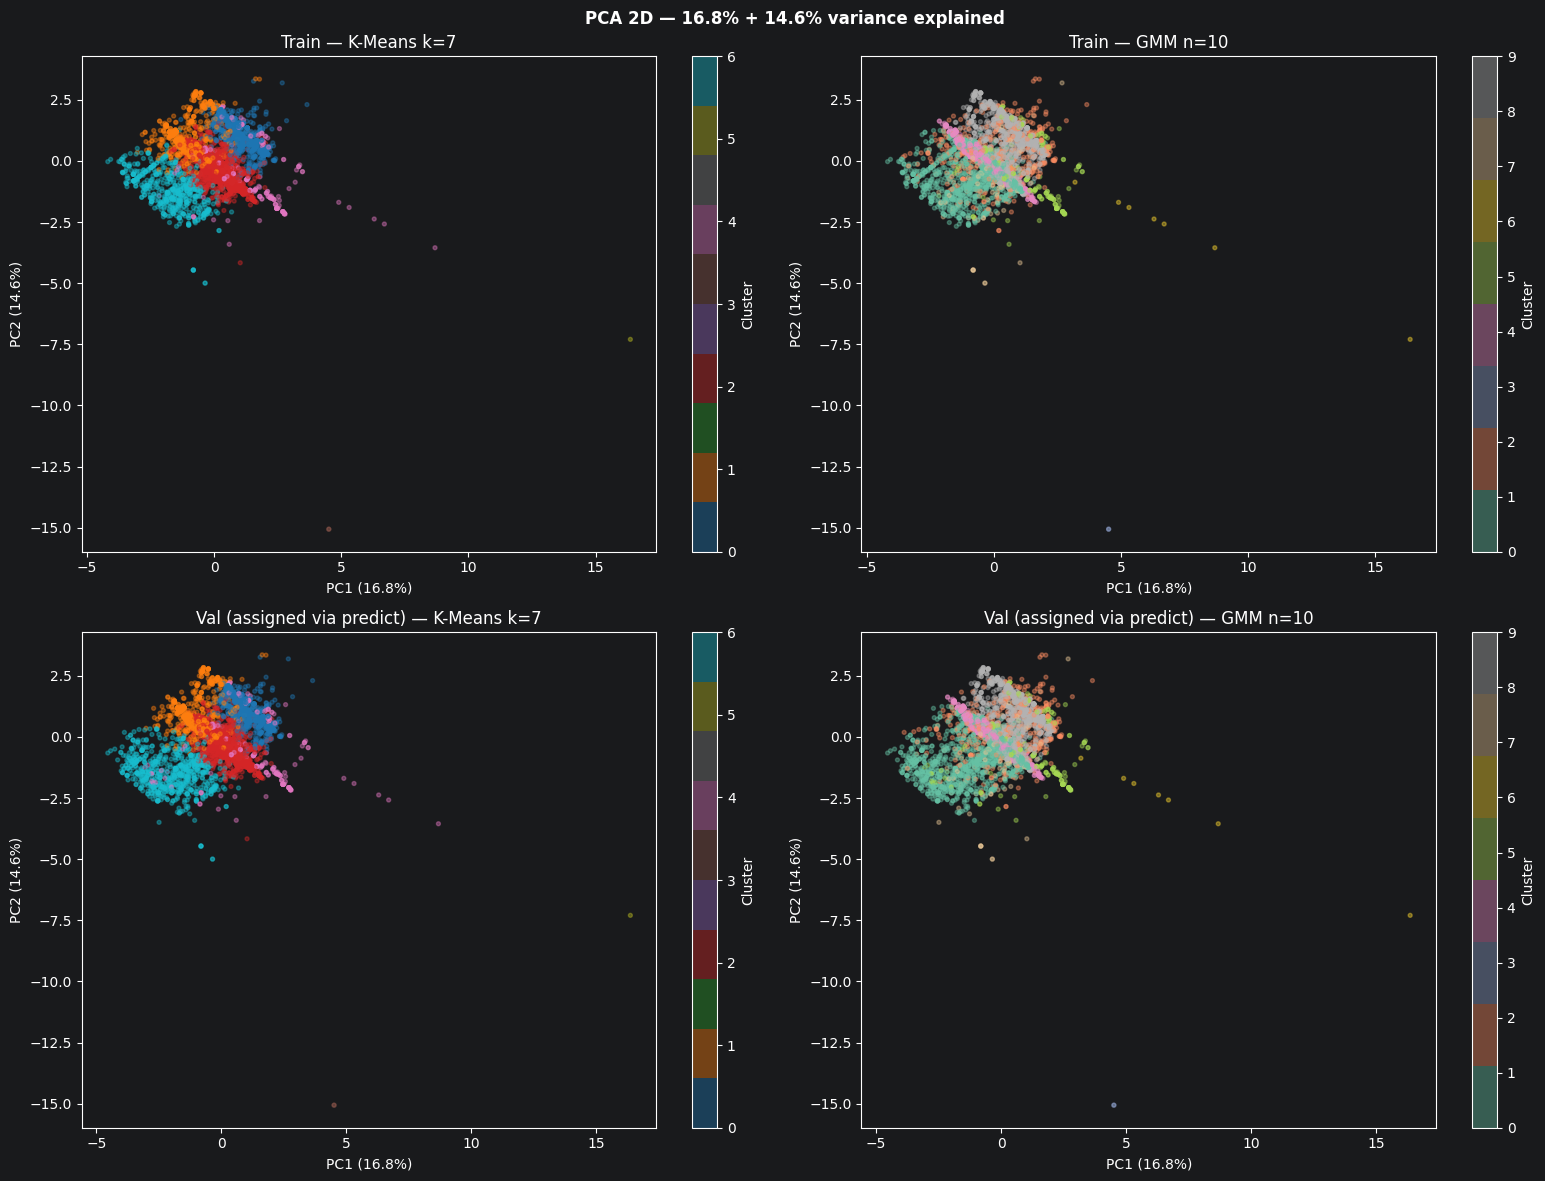

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca_train = pca.fit_transform(X_train)
X_pca_val   = pca.transform(X_val)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'PCA 2D — {var_explained[0]:.1%} + {var_explained[1]:.1%} variance explained',
             fontweight='bold')

for row, (X_pca, mat_set, split) in enumerate([
    (X_pca_train, mat_train, 'Train'),
    (X_pca_val,   mat_val,   'Val (assigned via predict)'),
]):
    for col_idx, (cluster_col, title, n_c, cmap) in enumerate([
        ('KMEANS_CLUSTER', f'K-Means k={K_FINAL}', K_FINAL, 'tab10'),
        ('GMM_CLUSTER',    f'GMM n={N_FINAL}',     N_FINAL, 'Set2'),
    ]):
        ax = axes[row][col_idx]
        sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=mat_set[cluster_col],
                        cmap=cmap, alpha=0.4, s=8)
        ax.set_title(f'{split} — {title}')
        ax.set_xlabel(f'PC1 ({var_explained[0]:.1%})')
        ax.set_ylabel(f'PC2 ({var_explained[1]:.1%})')
        plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout(); plt.show()


### Step 11 — K-Means vs GMM Agreement

In [13]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(mat_train['KMEANS_CLUSTER'], mat_train['GMM_CLUSTER'])
print(f'Adjusted Rand Index (K-Means vs GMM) on training set: {ari:.4f}')
print('  > 0.9 = very similar  |  ~0.5 = partial overlap  |  ~0 = independent')
print()
ct = pd.crosstab(mat_train['KMEANS_CLUSTER'], mat_train['GMM_CLUSTER'],
                 rownames=['KMeans'], colnames=['GMM'])
print('Cluster assignment crosstab (training):')
display(ct)


Adjusted Rand Index (K-Means vs GMM) on training set: 0.2465
  > 0.9 = very similar  |  ~0.5 = partial overlap  |  ~0 = independent

Cluster assignment crosstab (training):


GMM,0,1,2,3,4,5,6,7,8,9
KMeans,,,,,,,,,,
0,0,0,226,0,0,0,0,21,17,707
1,79,0,93,0,310,0,0,3,195,0
2,98,1060,139,0,259,0,0,37,3,811
3,0,0,0,2,0,0,0,0,0,0
4,0,0,0,0,0,229,6,0,0,0
5,0,0,0,0,0,0,1,0,0,0
6,169,318,80,0,0,0,0,33,0,0


### Step 12 — Merge Cluster Labels Back to Time-Series Data

In [14]:
# Cluster labels for downstream RF
label_cols = ['COPA_MTRL_NUM','KMEANS_CLUSTER','GMM_CLUSTER','GMM_MAX_PROB']

train_clustered = train_df.merge(mat_train[label_cols], on='COPA_MTRL_NUM', how='left')
val_clustered   = val_df.merge(mat_val[label_cols],     on='COPA_MTRL_NUM', how='left')

print('Training time-series with cluster labels:')
print(f'  Rows: {len(train_clustered):,}  |  matched: {train_clustered["KMEANS_CLUSTER"].notna().sum():,}')
print('Validation time-series with cluster labels:')
print(f'  Rows: {len(val_clustered):,}  |  matched: {val_clustered["KMEANS_CLUSTER"].notna().sum():,}')
print()
print('Val KMeans cluster distribution:')
print(val_clustered['KMEANS_CLUSTER'].value_counts().sort_index())


Training time-series with cluster labels:
  Rows: 109,530  |  matched: 108,452
Validation time-series with cluster labels:
  Rows: 61,232  |  matched: 57,594

Val KMeans cluster distribution:
KMEANS_CLUSTER
0.0    11610
1.0     7944
2.0    27826
3.0       24
4.0     2873
5.0        8
6.0     7309
Name: count, dtype: int64


### Step 13 — Export for Downstream Random Forest

In [15]:
# Per-material summaries
mat_train.to_csv('../data/real_data/material_clusters_train.csv', index=False)
mat_val.to_csv('../data/real_data/material_clusters_val.csv',     index=False)

# Full time-series with cluster labels
train_clustered.to_csv('../data/real_data/Active_COPA_data_v2_train_clustered.csv', index=False)
val_clustered.to_csv('../data/real_data/Active_COPA_data_v2_val_clustered.csv',     index=False)

print('Exported:')
print(f'  material_clusters_train.csv          — {len(mat_train):,} materials')
print(f'  material_clusters_val.csv            — {len(mat_val):,} materials')
print(f'  Active_COPA_data_v2_train_clustered.csv — {len(train_clustered):,} rows')
print(f'  Active_COPA_data_v2_val_clustered.csv   — {len(val_clustered):,} rows')
print()
print('Columns added for downstream RF:')
print('  KMEANS_CLUSTER  — integer (K-Means, fit on training only)')
print('  GMM_CLUSTER     — integer (GMM hard assignment, fit on training only)')
print('  GMM_MAX_PROB    — float   (GMM soft probability, confidence of assignment)')


Exported:
  material_clusters_train.csv          — 4,896 materials
  material_clusters_val.csv            — 5,048 materials
  Active_COPA_data_v2_train_clustered.csv — 109,530 rows
  Active_COPA_data_v2_val_clustered.csv   — 61,232 rows

Columns added for downstream RF:
  KMEANS_CLUSTER  — integer (K-Means, fit on training only)
  GMM_CLUSTER     — integer (GMM hard assignment, fit on training only)
  GMM_MAX_PROB    — float   (GMM soft probability, confidence of assignment)


### Step 14 — Per-Cluster Gradient Boosted Tree Models
For each clustering method (K-Means + GMM), train a separate GBT classifier and regressor per cluster.

- **Classifier target**: will price change next month? (`TGT_CHANGE_NEXT` = next-period `PRICE_CHANGED`)
- **Regressor target**: what will next month's WAC be? (`TGT_NEXT_WAC` = next-period `BASELINE_WAC_PRICE`)
- Cluster label is **not** included as a feature (the model is already scoped to that cluster)


In [16]:
# ── Feature prep for per-cluster GBT ──
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Derive leakage-free targets on full df, then propagate to splits
df['TGT_CHANGE_NEXT'] = (
    df.sort_values(['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'])
      .groupby('COPA_MTRL_NUM')['PRICE_CHANGED']
      .shift(-1)
)
df['TGT_NEXT_WAC'] = (
    df.sort_values(['COPA_MTRL_NUM','WAC_PRICE_COPA_DATE'])
      .groupby('COPA_MTRL_NUM')['BASELINE_WAC_PRICE']
      .shift(-1)
)

# Re-slice splits to pick up new target columns
train_df_t = df[df['WAC_PRICE_COPA_DATE'] <  pd.Timestamp(TRAIN_CUTOFF)].copy()
val_df_t   = df[(df['WAC_PRICE_COPA_DATE'] >= pd.Timestamp(TRAIN_CUTOFF)) &
                (df['WAC_PRICE_COPA_DATE'] <  pd.Timestamp(VAL_END))].copy()

# Merge cluster labels
label_cols_full = ['COPA_MTRL_NUM','KMEANS_CLUSTER','GMM_CLUSTER','GMM_MAX_PROB']
train_cl = train_df_t.merge(mat_train[label_cols_full], on='COPA_MTRL_NUM', how='inner')
val_cl   = val_df_t.merge(mat_val[label_cols_full],     on='COPA_MTRL_NUM', how='inner')

# Drop rows where target is unknown (last month per material)
train_cl = train_cl.dropna(subset=['TGT_CHANGE_NEXT','TGT_NEXT_WAC']).copy()
val_cl   = val_cl.dropna(subset=['TGT_CHANGE_NEXT','TGT_NEXT_WAC']).copy()

# Columns to drop before modeling
DROP_COLS = [
    'COPA_MTRL_NUM','COPA_NDC_NUM','SNW_NDC_NUM','SNW_MTRL_NUM',
    'WAC_PRICE_COPA_DATE','IS_FUTURE_PERIOD_FLAG','COPA_FISCAL_YEAR_PERIOD',
    'BASELINE_WAC_PRICE','PREV_PERIOD_BASELINE_WAC_PRICE',  # price level = reg target
    'TGT_CHANGE_NEXT','TGT_NEXT_WAC',                       # targets
    'KMEANS_CLUSTER','GMM_CLUSTER','GMM_MAX_PROB',           # cluster labels (scoped per model)
    'PRICE_CHANGED',                                         # current-period flag leaks clf target
]

# Encode categoricals + date columns — fit on training only
le_gbt = LabelEncoder()
train_cl['CUST_PROD_CATEGORY'] = le_gbt.fit_transform(train_cl['CUST_PROD_CATEGORY'].fillna('UNKNOWN').astype(str))
val_cl['CUST_PROD_CATEGORY']   = val_cl['CUST_PROD_CATEGORY'].fillna('UNKNOWN').astype(str).apply(
    lambda x: le_gbt.transform([x])[0] if x in le_gbt.classes_ else 0
)
le_src = LabelEncoder()
for col in ['PREFERRED_SOURCE','EFFECTIVE_SOURCE']:
    train_cl[col] = le_src.fit_transform(train_cl[col].fillna('UNKNOWN').astype(str))
    val_cl[col]   = val_cl[col].fillna('UNKNOWN').astype(str).apply(
        lambda x: le_src.transform([x])[0] if x in le_src.classes_ else 0
    )
for col in ['SNW_FIRST_EFF_DATE','SNW_LAST_EFF_DATE','SNW_PRC_EFF_DT']:
    for d in [train_cl, val_cl]:
        d[col] = pd.to_datetime(d[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notna(x) else -1
        )
for col in train_cl.select_dtypes(include=['object']).columns:
    if col not in DROP_COLS:
        enc = LabelEncoder()
        train_cl[col] = enc.fit_transform(train_cl[col].astype(str))
        val_cl[col]   = val_cl[col].astype(str).apply(
            lambda x: enc.transform([x])[0] if x in enc.classes_ else 0
        )

FEATURE_COLS = [c for c in train_cl.columns if c not in DROP_COLS]
print(f'Training rows  : {len(train_cl):,}')
print(f'Validation rows: {len(val_cl):,}')
print(f'Feature columns: {len(FEATURE_COLS)}')
print(FEATURE_COLS)


Training rows  : 108,370
Validation rows: 57,455
Feature columns: 26
['COPA_WAC_PRICE', 'PREV_PERIOD_COPA_WAC_PRICE', 'CUST_PROD_CATEGORY', 'SNW_FIRST_EFF_DATE', 'SNW_LAST_EFF_DATE', 'SNW_PRC_EFF_DT', 'SNW_WAC_PRICE', 'SELL_DSCR', 'NET_REVENUE', 'PREV_PERIOD_SNW_WAC_PRICE', 'COPA_SNW_WAC_PRICE_MATCH_IND', 'COPA_MOM_VAR_PCT', 'SNW_MOM_VAR_PCT', 'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE', 'SNW_NULL_MONTHS_ROLLING', 'TOTAL_MONTHS_ROLLING', 'PREFERRED_SOURCE', 'EFFECTIVE_SOURCE', 'MATERIAL_CUMULATIVE_REVENUE', 'TOTAL_CUMULATIVE_REVENUE', 'BASELINE_MOM_VAR_PCT', 'CUMULATIVE_REVENUE_PCT_CONTRIBUTION', 'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME', 'LOE_YEAR']


In [17]:
# ── Helper: train & evaluate per-cluster GBT classifier + regressor ──
def run_per_cluster_gbt(train_df, val_df, cluster_col, feature_cols, label):
    clusters  = sorted(train_df[cluster_col].dropna().unique())
    clf_rows, reg_rows = [], []
    all_clf_true, all_clf_pred = [], []
    all_reg_true, all_reg_pred = [], []

    for c in clusters:
        tr = train_df[train_df[cluster_col] == c]
        va = val_df[val_df[cluster_col] == c]
        if len(tr) < 50 or len(va) < 10:
            print(f'  Cluster {c}: skipped (train={len(tr)}, val={len(va)})')
            continue

        X_tr = tr[feature_cols].fillna(0)
        X_va = va[feature_cols].fillna(0)

        # Classifier — skip if only one class in training data
        from sklearn.metrics import f1_score, precision_score, recall_score
        if tr['TGT_CHANGE_NEXT'].nunique() < 2:
            print(f'  Cluster {c}: classifier skipped — only one class in training (all no-change)')
        else:
            clf = HistGradientBoostingClassifier(
                max_iter=200, max_depth=5, learning_rate=0.05,
                class_weight='balanced', random_state=42
            )
            clf.fit(X_tr, tr['TGT_CHANGE_NEXT'].astype(int))
            y_clf_pred = clf.predict(X_va)
            y_clf_true = va['TGT_CHANGE_NEXT'].astype(int)
            all_clf_true.extend(y_clf_true); all_clf_pred.extend(y_clf_pred)
            clf_rows.append({
                'Cluster': c, 'N_Train': len(tr), 'N_Val': len(va),
                'Precision': precision_score(y_clf_true, y_clf_pred, zero_division=0),
                'Recall':    recall_score(y_clf_true, y_clf_pred, zero_division=0),
                'F1':        f1_score(y_clf_true, y_clf_pred, zero_division=0),
            })

        # Regressor
        reg = HistGradientBoostingRegressor(
            max_iter=200, max_depth=5, learning_rate=0.05, random_state=42
        )
        reg.fit(X_tr, tr['TGT_NEXT_WAC'])
        y_reg_pred = reg.predict(X_va)
        y_reg_true = va['TGT_NEXT_WAC'].values
        all_reg_true.extend(y_reg_true); all_reg_pred.extend(y_reg_pred)

        wape = np.sum(np.abs(y_reg_true - y_reg_pred)) / np.sum(np.abs(y_reg_true))
        reg_rows.append({
            'Cluster': c, 'N_Train': len(tr), 'N_Val': len(va),
            'Dollar_WAPE': round(wape, 4),
            'Median_AbsErr': round(np.median(np.abs(y_reg_true - y_reg_pred)), 2),
        })

    print(f'\n── {label} — Per-Cluster GBT Classifier ──')
    clf_df = pd.DataFrame(clf_rows)
    print(clf_df.round(4).to_string(index=False))

    from sklearn.metrics import f1_score as f1
    overall_f1 = f1(all_clf_true, all_clf_pred, zero_division=0)
    print(f'Overall F1 (all clusters combined): {overall_f1:.4f}')
    print(classification_report(all_clf_true, all_clf_pred,
                                target_names=['No Change','Price Change']))

    print(f'\n── {label} — Per-Cluster GBT Regressor ──')
    reg_df = pd.DataFrame(reg_rows)
    print(reg_df.to_string(index=False))

    all_reg_true = np.array(all_reg_true)
    all_reg_pred = np.array(all_reg_pred)
    overall_wape = np.sum(np.abs(all_reg_true - all_reg_pred)) / np.sum(np.abs(all_reg_true))
    print(f'Overall Dollar WAPE (all clusters combined): {overall_wape*100:.2f}%')

    # Bar chart — Regressor WAPE (separate figure to avoid shape mismatch from different cluster counts)
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    fig1.suptitle(f'{label} — Per-Cluster GBT Regressor WAPE', fontweight='bold')
    ax1.bar(reg_df['Cluster'].astype(str), reg_df['Dollar_WAPE']*100,
            color='seagreen', edgecolor='white')
    ax1.axhline(overall_wape*100, color='red', linestyle='--',
                label=f'Overall {overall_wape*100:.2f}%')
    ax1.set_xlabel('Cluster'); ax1.set_ylabel('Dollar WAPE (%)')
    ax1.set_title('Regressor Dollar WAPE per Cluster'); ax1.legend()
    plt.tight_layout(); plt.show()

    # Bar chart — Classifier F1
    if not clf_df.empty:
        fig2, ax2 = plt.subplots(figsize=(8, 5))
        fig2.suptitle(f'{label} — Per-Cluster GBT Classifier F1', fontweight='bold')
        ax2.bar(clf_df['Cluster'].astype(str), clf_df['F1'],
                color='steelblue', edgecolor='white')
        ax2.axhline(overall_f1, color='red', linestyle='--',
                    label=f'Overall F1 {overall_f1:.3f}')
        ax2.set_xlabel('Cluster'); ax2.set_ylabel('F1 Score')
        ax2.set_title('Classifier F1 per Cluster'); ax2.legend()
        plt.tight_layout(); plt.show()
    return clf_df, reg_df

print('Helper function defined.')


Helper function defined.


  Cluster 3: skipped (train=48, val=24)
  Cluster 5: skipped (train=24, val=7)

── K-Means (k=7) — Per-Cluster GBT Classifier ──
 Cluster  N_Train  N_Val  Precision  Recall     F1
       0    23431  11602     0.1273  0.0132 0.0239
       1    15802   7939     0.4838  0.2193 0.3018
       2    56986  27769     0.5027  0.5071 0.5049
       4     5442   2863     0.6735  0.4646 0.5499
       6     6637   7251     0.1858  0.0948 0.1255
Overall F1 (all clusters combined): 0.4055
              precision    recall  f1-score   support

   No Change       0.94      0.97      0.96     52708
Price Change       0.49      0.34      0.41      4716

    accuracy                           0.92     57424
   macro avg       0.72      0.66      0.68     57424
weighted avg       0.91      0.92      0.91     57424


── K-Means (k=7) — Per-Cluster GBT Regressor ──
 Cluster  N_Train  N_Val  Dollar_WAPE  Median_AbsErr
       0    23431  11602       0.0536          17.20
       1    15802   7939       0.0279   

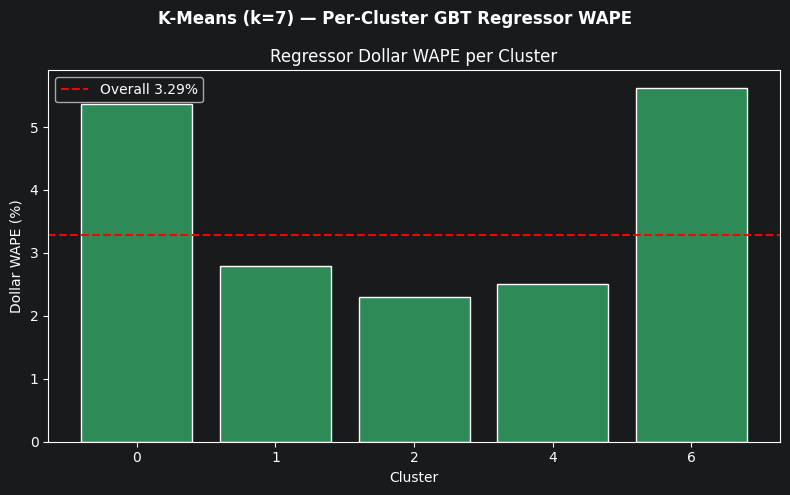

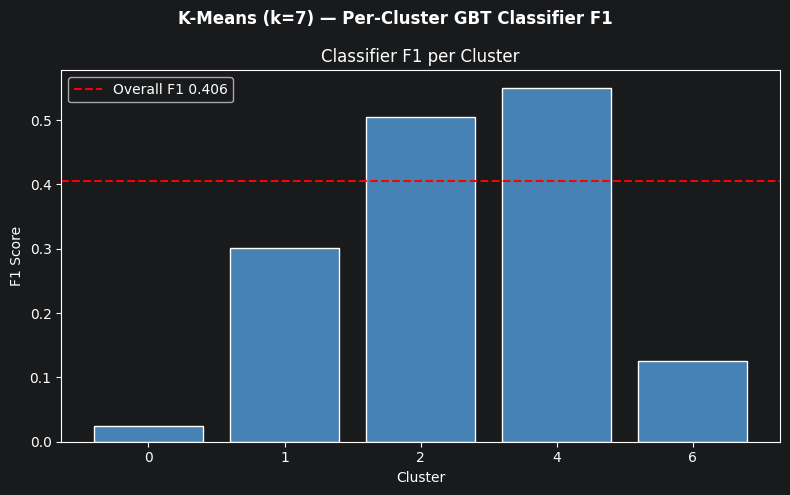

In [18]:
# ── Per-cluster GBT — K-Means clusters ──
clf_km, reg_km = run_per_cluster_gbt(
    train_cl, val_cl,
    cluster_col='KMEANS_CLUSTER',
    feature_cols=FEATURE_COLS,
    label=f'K-Means (k={K_FINAL})'
)


  Cluster 3: skipped (train=48, val=24)
  Cluster 6: classifier skipped — only one class in training (all no-change)

── GMM (n=10) — Per-Cluster GBT Classifier ──
 Cluster  N_Train  N_Val  Precision  Recall     F1
       0     5679   4675     0.3056  0.0655 0.1078
       1    28371  15383     0.3153  0.3385 0.3265
       2    11817   6042     0.4046  0.1556 0.2247
       4    13656   6836     0.5052  0.5000 0.5026
       5     5298   2821     0.7009  0.4249 0.5291
       7     1741   1006     0.6923  0.1837 0.2903
       8     5160   2555     1.0000  0.0037 0.0073
       9    36432  18064     0.4777  0.2786 0.3520
Overall F1 (all clusters combined): 0.3685
              precision    recall  f1-score   support

   No Change       0.94      0.97      0.95     52666
Price Change       0.48      0.30      0.37      4716

    accuracy                           0.92     57382
   macro avg       0.71      0.64      0.66     57382
weighted avg       0.90      0.92      0.91     57382


── GMM

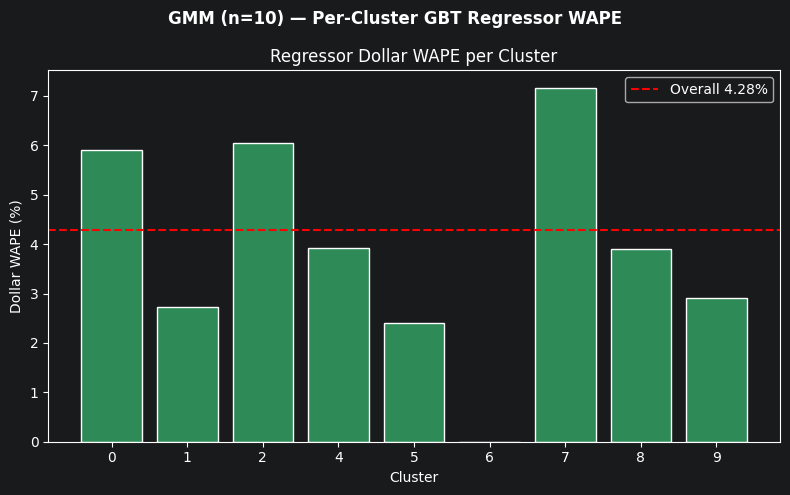

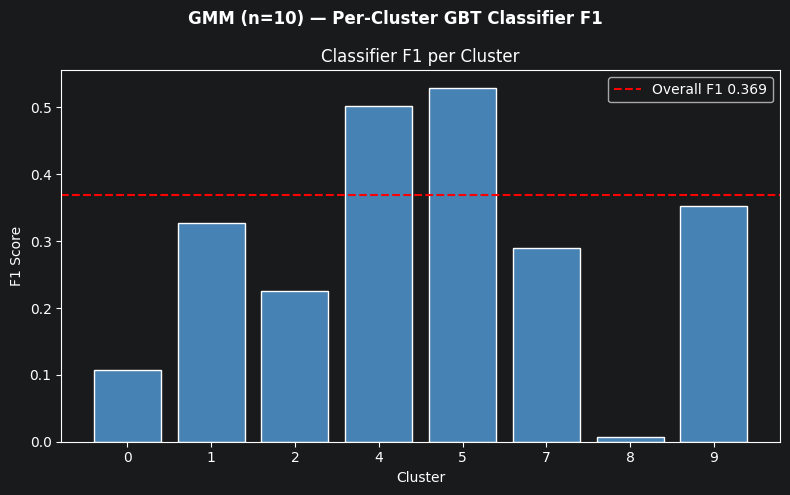

In [19]:
# ── Per-cluster GBT — GMM clusters ──
clf_gmm, reg_gmm = run_per_cluster_gbt(
    train_cl, val_cl,
    cluster_col='GMM_CLUSTER',
    feature_cols=FEATURE_COLS,
    label=f'GMM (n={N_FINAL})'
)


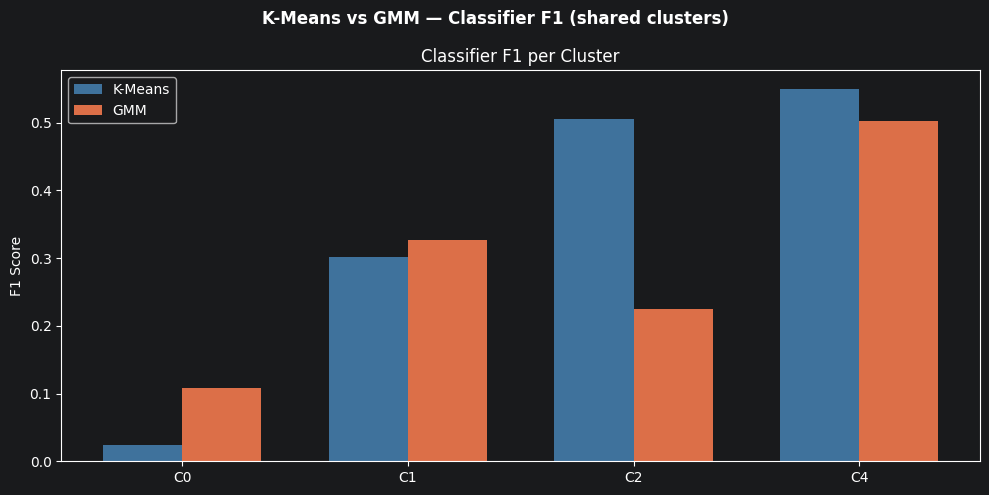

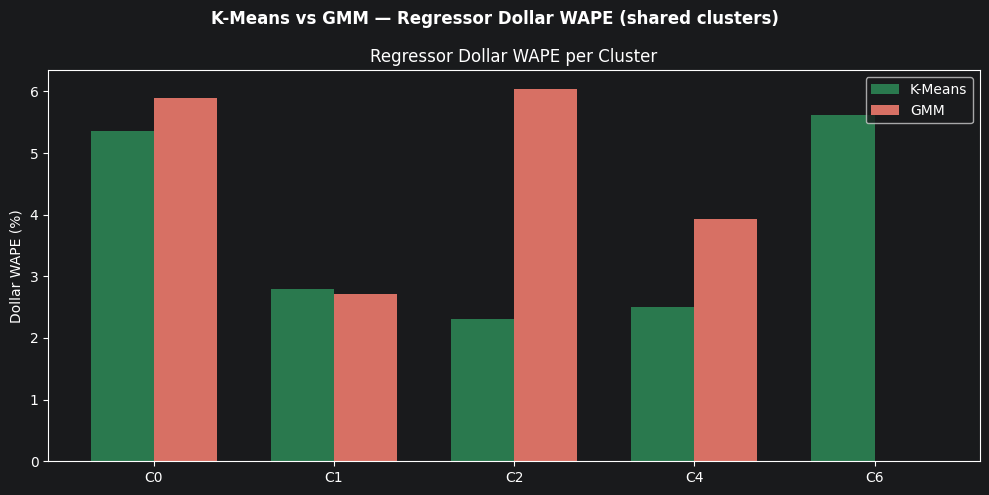

In [20]:
# ── K-Means vs GMM: per-cluster GBT summary comparison ──
# Classifier and Regressor may cover different cluster sets, so plot separately.

# --- Classifier F1 (only clusters that ran the classifier in both methods) ---
common_clf = sorted(set(clf_km['Cluster']) & set(clf_gmm['Cluster']))
if common_clf:
    km_f1  = clf_km[clf_km['Cluster'].isin(common_clf)].set_index('Cluster').loc[common_clf, 'F1'].values
    gmm_f1 = clf_gmm[clf_gmm['Cluster'].isin(common_clf)].set_index('Cluster').loc[common_clf, 'F1'].values
    x = np.arange(len(common_clf)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('K-Means vs GMM — Classifier F1 (shared clusters)', fontweight='bold')
    ax.bar(x - w/2, km_f1,  w, label='K-Means', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, gmm_f1, w, label='GMM',     color='coral',     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f'C{c}' for c in common_clf])
    ax.set_ylabel('F1 Score'); ax.set_title('Classifier F1 per Cluster'); ax.legend()
    plt.tight_layout(); plt.show()

# --- Regressor WAPE (only clusters that ran regressor in both methods) ---
common_reg = sorted(set(reg_km['Cluster']) & set(reg_gmm['Cluster']))
if common_reg:
    km_wape  = reg_km[reg_km['Cluster'].isin(common_reg)].set_index('Cluster').loc[common_reg, 'Dollar_WAPE'].values * 100
    gmm_wape = reg_gmm[reg_gmm['Cluster'].isin(common_reg)].set_index('Cluster').loc[common_reg, 'Dollar_WAPE'].values * 100
    x2 = np.arange(len(common_reg)); w = 0.35
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    fig2.suptitle('K-Means vs GMM — Regressor Dollar WAPE (shared clusters)', fontweight='bold')
    ax2.bar(x2 - w/2, km_wape,  w, label='K-Means', color='seagreen', alpha=0.85)
    ax2.bar(x2 + w/2, gmm_wape, w, label='GMM',     color='salmon',   alpha=0.85)
    ax2.set_xticks(x2); ax2.set_xticklabels([f'C{c}' for c in common_reg])
    ax2.set_ylabel('Dollar WAPE (%)'); ax2.set_title('Regressor Dollar WAPE per Cluster'); ax2.legend()
    plt.tight_layout(); plt.show()


In [21]:
# ── K-Means Cluster 3 — Deep Drill-Down ──────────────────────────────────────
TARGET_CLUSTER = 3

c3_mat = mat_train[mat_train['KMEANS_CLUSTER'] == TARGET_CLUSTER].copy()
print(f'Materials in Cluster {TARGET_CLUSTER}: {len(c3_mat)}')
print(f'Product category breakdown:')
print(c3_mat['CUST_PROD_CATEGORY'].value_counts().to_string())

# Full per-material summary sorted by AVG_WAC descending
summary_cols = [
    'COPA_MTRL_NUM', 'CUST_PROD_CATEGORY',
    'TENURE_MONTHS', 'PREF_SNW_RATE', 'AVG_COPA_VARIANCE', 'AVG_SNW_VARIANCE',
    'CHANGE_FREQ', 'N_PRICE_CHANGES', 'AVG_CHANGE_PCT', 'MAX_CHANGE_PCT',
    'AVG_WAC', 'CV_WAC'
]
summary_cols = [c for c in summary_cols if c in c3_mat.columns]
print(f'\n--- All materials in Cluster {TARGET_CLUSTER} (sorted by AVG_WAC desc) ---')
print(c3_mat[summary_cols].sort_values('AVG_WAC', ascending=False).reset_index(drop=True).to_string())

# Join SELL_DSCR from raw time-series for readable product names
name_map = (
    df[['COPA_MTRL_NUM', 'SELL_DSCR']]
    .drop_duplicates('COPA_MTRL_NUM')
    .set_index('COPA_MTRL_NUM')['SELL_DSCR']
)
c3_mat['PRODUCT_NAME'] = c3_mat['COPA_MTRL_NUM'].map(name_map)

named_cols = ['PRODUCT_NAME', 'CUST_PROD_CATEGORY', 'TENURE_MONTHS',
              'CHANGE_FREQ', 'AVG_CHANGE_PCT', 'AVG_WAC', 'CV_WAC']
named_cols = [c for c in named_cols if c in c3_mat.columns]
print(f'\n--- Cluster {TARGET_CLUSTER}: named products sorted by AVG_WAC ---')
print(c3_mat[named_cols].sort_values('AVG_WAC', ascending=False).reset_index(drop=True).to_string())

# Export full cluster 3 rows from time-series data
c3_mtrls = c3_mat['COPA_MTRL_NUM'].unique()
c3_timeseries = df[df['COPA_MTRL_NUM'].isin(c3_mtrls)].copy()
c3_timeseries = c3_timeseries.merge(
    c3_mat[['COPA_MTRL_NUM', 'KMEANS_CLUSTER', 'PRODUCT_NAME']],
    on='COPA_MTRL_NUM', how='left'
)
c3_timeseries.to_csv('../data/real_data/cluster3_kmeans_timeseries.csv', index=False)
print(f'\nExported {len(c3_timeseries):,} time-series rows for {len(c3_mtrls)} materials -> data/real_data/cluster3_kmeans_timeseries.csv')


Materials in Cluster 3: 2
Product category breakdown:
CUST_PROD_CATEGORY
BX    2

--- All materials in Cluster 3 (sorted by AVG_WAC desc) ---
        COPA_MTRL_NUM CUST_PROD_CATEGORY  TENURE_MONTHS  PREF_SNW_RATE  AVG_COPA_VARIANCE  AVG_SNW_VARIANCE  CHANGE_FREQ  N_PRICE_CHANGES  AVG_CHANGE_PCT  MAX_CHANGE_PCT     AVG_WAC    CV_WAC
0  000000000002705234                 BX             24       0.083333           0.204358          1.478836        0.625               15        0.212907          2.2543  101.635833  0.380246
1  000000000002404820                 BX             24       0.083333           0.254974          1.478617        0.625               15        0.263380          2.9122   66.501250  0.481880

--- Cluster 3: named products sorted by AVG_WAC ---
                     PRODUCT_NAME CUST_PROD_CATEGORY  TENURE_MONTHS  CHANGE_FREQ  AVG_CHANGE_PCT     AVG_WAC    CV_WAC
0  INFUVITE PED SDV 2VL SYS BAX 5                 BX             24        0.625        0.212907  101.635833  